In [75]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix

In [28]:
df = pd.read_csv('processed_data.csv')
df = df.iloc[:,3:]
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 


In [30]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


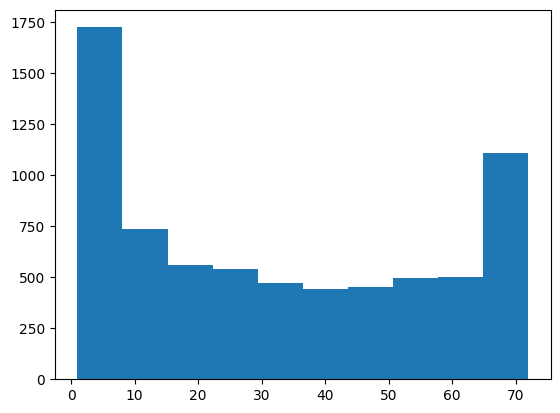

In [31]:
plt.hist(df['tenure']);

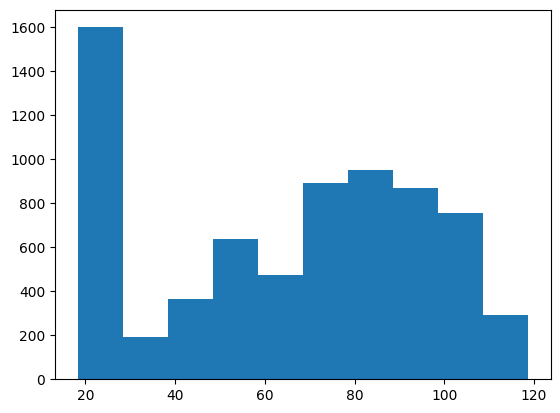

In [32]:
plt.hist(df['MonthlyCharges']);

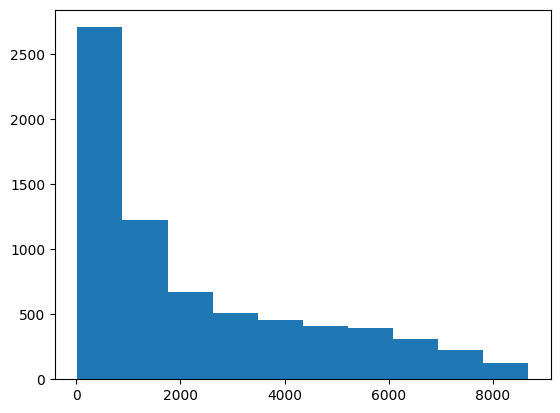

In [33]:
plt.hist(df['TotalCharges']);

# label encoding

In [1]:
df

NameError: name 'df' is not defined

In [35]:
obj_col= df.select_dtypes(include='object').columns
obj_col

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [38]:
for i in obj_col:
    le = LabelEncoder()
    df[i]= le.fit_transform(df[i])

In [39]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7028,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7029,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7030,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


In [40]:
df.corr()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001819,-0.001379,0.010349,0.005285,-0.007515,-0.006908,-0.002236,-0.014899,-0.011920,0.001348,-0.006695,-0.005624,-0.008920,0.000095,-0.011902,0.016942,-0.013779,0.000048,-0.008545
SeniorCitizen,-0.001819,1.000000,0.016957,-0.210550,0.015683,0.008392,0.146287,-0.032160,-0.127937,-0.013355,-0.021124,-0.151007,0.031019,0.047088,-0.141820,0.156258,-0.038158,0.219874,0.102411,0.150541
Partner,-0.001379,0.016957,1.000000,0.452269,0.381912,0.018397,0.142717,0.000513,0.150610,0.153045,0.165614,0.126488,0.136679,0.129907,0.294094,-0.013957,-0.156232,0.097825,0.319072,-0.149982
Dependents,0.010349,-0.210550,0.452269,1.000000,0.163386,-0.001078,-0.024975,0.044030,0.151198,0.090231,0.079723,0.132530,0.046214,0.022088,0.240556,-0.110131,-0.041989,-0.112343,0.064653,-0.163128
tenure,0.005285,0.015683,0.381912,0.163386,1.000000,0.007877,0.343673,-0.029835,0.327283,0.372434,0.372669,0.324729,0.290572,0.296785,0.676734,0.004823,-0.370087,0.246862,0.825880,-0.354049
PhoneService,-0.007515,0.008392,0.018397,-0.001078,0.007877,1.000000,-0.020504,0.387266,-0.014163,0.024040,0.004718,-0.018136,0.056393,0.043025,0.003019,0.016696,-0.005499,0.248033,0.113008,0.011691
MultipleLines,-0.006908,0.146287,0.142717,-0.024975,0.343673,-0.020504,1.000000,-0.108849,0.007306,0.117276,0.122614,0.010941,0.175403,0.181705,0.111029,0.165306,-0.176598,0.433905,0.453202,0.038043
InternetService,-0.002236,-0.032160,0.000513,0.044030,-0.029835,0.387266,-0.108849,1.000000,-0.028003,0.036735,0.045558,-0.025626,0.108190,0.097967,0.099579,-0.138166,0.084504,-0.322173,-0.175691,-0.047097
OnlineSecurity,-0.014899,-0.127937,0.150610,0.151198,0.327283,-0.014163,0.007306,-0.028003,1.000000,0.184942,0.175789,0.284875,0.044399,0.056313,0.373980,-0.157723,-0.096593,-0.053576,0.254473,-0.289050
OnlineBackup,-0.011920,-0.013355,0.153045,0.090231,0.372434,0.024040,0.117276,0.036735,0.184942,1.000000,0.187646,0.195581,0.147085,0.137083,0.280617,-0.012697,-0.125534,0.119943,0.375556,-0.195290


<Axes: >

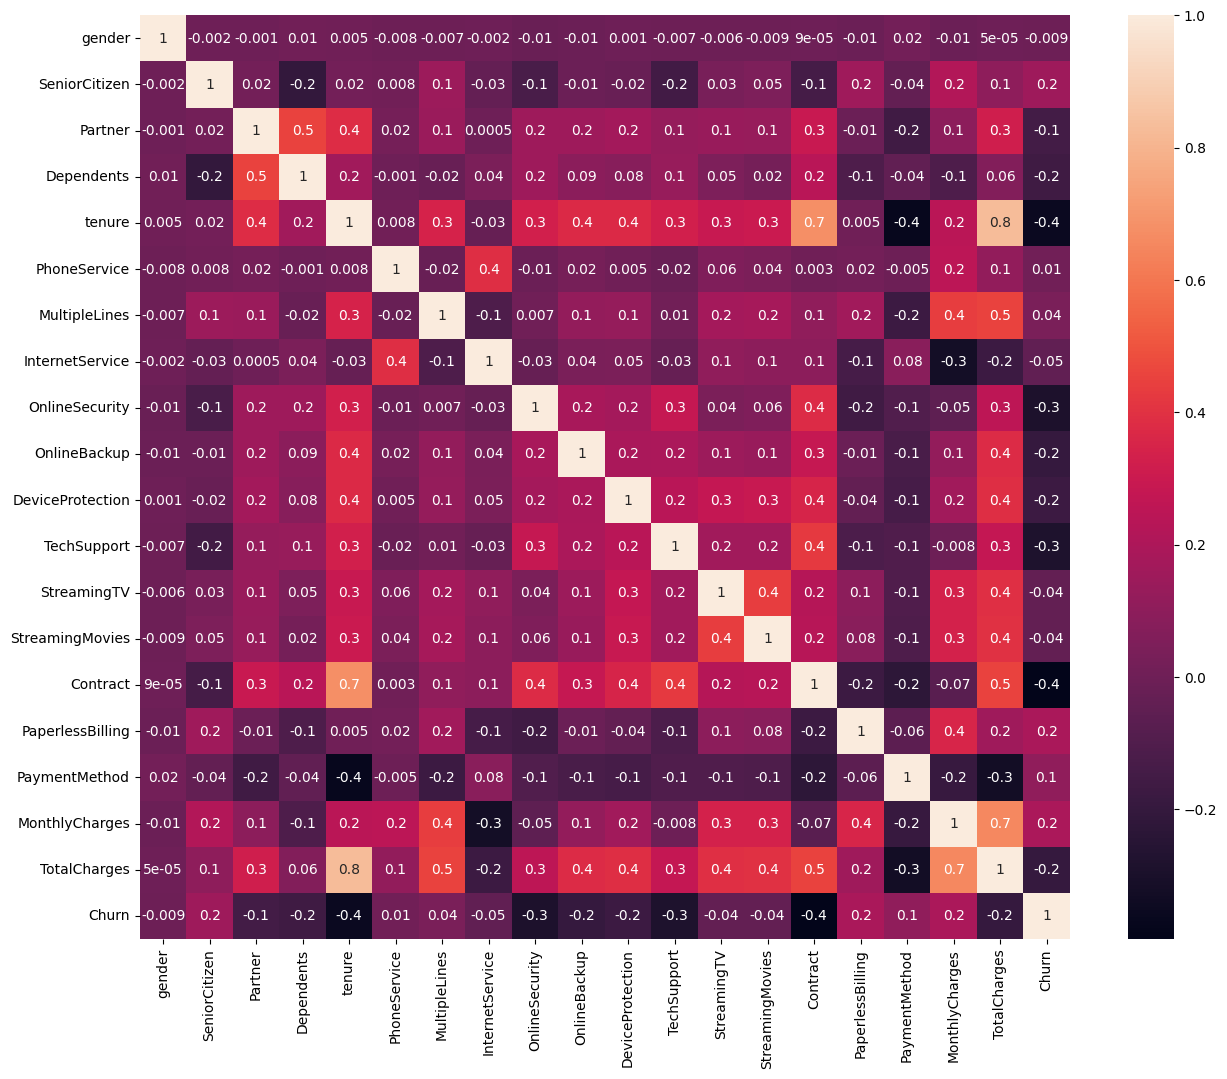

In [43]:
import seaborn as sns
plt.figure(figsize=(15,12))
sns.heatmap(df.corr(),annot=True,fmt = '0.0g')

# feature selction

In [44]:
df.corr()['Churn']


gender             -0.008545
SeniorCitizen       0.150541
Partner            -0.149982
Dependents         -0.163128
tenure             -0.354049
PhoneService        0.011691
MultipleLines       0.038043
InternetService    -0.047097
OnlineSecurity     -0.289050
OnlineBackup       -0.195290
DeviceProtection   -0.177883
TechSupport        -0.282232
StreamingTV        -0.036303
StreamingMovies    -0.038802
Contract           -0.396150
PaperlessBilling    0.191454
PaymentMethod       0.107852
MonthlyCharges      0.192858
TotalCharges       -0.199484
Churn               1.000000
Name: Churn, dtype: float64

In [46]:
X = df.drop('Churn',axis = 1) 
y = df['Churn']

In [47]:
from sklearn.tree import DecisionTreeClassifier

In [48]:
dt = DecisionTreeClassifier() # model for feature selection
dt.fit(X,y)

DecisionTreeClassifier()

In [50]:
dt.feature_importances_

array([0.02567939, 0.01920825, 0.01642423, 0.0184318 , 0.10871657,
       0.00186579, 0.01764303, 0.02896139, 0.04608379, 0.01177966,
       0.01737128, 0.01735203, 0.01193336, 0.01144195, 0.16930023,
       0.01571339, 0.04036521, 0.1997777 , 0.22195096])

In [51]:
dt.feature_names_in_

array(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges'], dtype=object)

In [ ]:

# gender             -0.008545
# PhoneService        0.011691
# MultipleLines       0.038043
# InternetService    -0.047097
# StreamingTV        -0.036303
# StreamingMovies    -0.038802

In [54]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

In [55]:
model = LogisticRegression(max_iter=400)
rfe = RFE(model, n_features_to_select=8)

fit = rfe.fit(X, y)
fit.support_

array([False,  True, False,  True, False,  True, False, False,  True,
        True, False,  True, False, False,  True,  True, False, False,
       False])

In [56]:
fit.feature_names_in_

array(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges'], dtype=object)

In [57]:
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier()
et.fit(X,y)
et.feature_importances_

array([0.03827336, 0.02598534, 0.0302641 , 0.02426818, 0.1531005 ,
       0.00682228, 0.02654906, 0.03977078, 0.04273336, 0.03139981,
       0.02964976, 0.03891662, 0.02381347, 0.02291056, 0.08215787,
       0.03180178, 0.06426584, 0.13712235, 0.150195  ])

In [58]:
et.feature_names_in_

array(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges'], dtype=object)

In [ ]:
# gender             -0.008545
# PhoneService        0.011691
# MultipleLines       0.038043
# InternetService    -0.047097
# StreamingTV        -0.036303
# StreamingMovies    -0.038802

In [60]:
df.drop(['gender','PhoneService','MultipleLines','InternetService','StreamingTV','StreamingMovies'],axis=1, inplace=True)

In [61]:
df

,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,0,2,0,0,0,1,2,29.85,29.85,0
1,0,0,0,34,2,0,2,0,1,0,3,56.95,1889.50,0
2,0,0,0,2,2,2,0,0,0,1,3,53.85,108.15,1
3,0,0,0,45,2,0,2,2,1,0,0,42.30,1840.75,0
4,0,0,0,2,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,1,1,24,2,0,2,2,1,1,3,84.80,1990.50,0
7028,0,1,1,72,0,2,2,0,1,1,1,103.20,7362.90,0
7029,0,1,1,11,2,0,0,0,0,1,2,29.60,346.45,0
7030,1,1,0,4,0,0,0,0,0,1,3,74.40,306.60,1


# split Data into feature and target or X / y

In [64]:
feature = df.iloc[:,:13]
target = df['Churn']

In [65]:

sc = StandardScaler()
x = sc.fit_transform(feature)

In [90]:
x

array([[-0.44032709,  1.03561683, -0.65230493, ...,  0.39980518,
        -1.16169394, -0.99419409],
       [-0.44032709, -0.9656081 , -0.65230493, ...,  1.33663626,
        -0.26087792, -0.17373982],
       [-0.44032709, -0.9656081 , -0.65230493, ...,  1.33663626,
        -0.36392329, -0.95964911],
       ...,
       [-0.44032709,  1.03561683,  1.53302536, ...,  0.39980518,
        -1.17000405, -0.85451414],
       [ 2.27103902,  1.03561683, -0.65230493, ...,  1.33663626,
         0.31916782, -0.87209546],
       [-0.44032709, -0.9656081 , -0.65230493, ..., -1.47385696,
         1.35793167,  2.01234407]])

# Create model






# Logistic Regression
# DT
# KNN
# RandomForest
# BaggingClassifier
# XGBoost
# SVM

In [70]:
X_train, X_test, y_train, y_test = train_test_split(x,target,test_size=0.25,random_state=0)

In [71]:

lr = LogisticRegression(max_iter=400)
lr.fit(X_train,y_train)

LogisticRegression(max_iter=400)

In [73]:
pred_lr =  lr.predict(X_test)

In [72]:
X_test.shape

(1758, 13)

In [74]:
pred_lr

array([0, 0, 0, ..., 1, 0, 0])

In [77]:
print(classification_report(y_test,pred_lr)) # found imbalnce data

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1311
           1       0.64      0.53      0.58       447

    accuracy                           0.80      1758
   macro avg       0.74      0.71      0.72      1758
weighted avg       0.79      0.80      0.80      1758



In [78]:
from sklearn.ensemble import RandomForestClassifier
re = RandomForestClassifier()
re.fit(X_train,y_train)

RandomForestClassifier()

In [79]:
pred_RF =  re.predict(X_test)
print(classification_report(y_test,pred_RF))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1311
           1       0.61      0.47      0.54       447

    accuracy                           0.79      1758
   macro avg       0.72      0.69      0.70      1758
weighted avg       0.78      0.79      0.78      1758



In [81]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [ ]:
# pip install imblearn


In [82]:
from imblearn.over_sampling import SMOTE

In [83]:
X_resample,Y_resample = SMOTE().fit_resample(x,target)

In [85]:
Y_resample.shape

(10326,)

In [86]:
X_train,X_test,Y_train,Y_test = train_test_split(X_resample,Y_resample,test_size=0.25,random_state=0)

In [87]:

lr1 = LogisticRegression(max_iter=400)
lr1.fit(X_train,Y_train)

LogisticRegression(max_iter=400)

In [88]:
lr1_pred = lr1.predict(X_test)

In [89]:
print(classification_report(Y_test,lr1_pred))

              precision    recall  f1-score   support

           0       0.79      0.72      0.76      1277
           1       0.75      0.81      0.78      1305

    accuracy                           0.77      2582
   macro avg       0.77      0.77      0.77      2582
weighted avg       0.77      0.77      0.77      2582



In [ ]:
# or kfold testing

In [91]:
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits = 10)
model1 = LogisticRegression()
result = cross_val_score(model1,X_resample,Y_resample,cv = kfold)

In [92]:
result

array([0.72700871, 0.74540174, 0.75121007, 0.7124879 , 0.71829622,
       0.73862536, 0.75096899, 0.77422481, 0.76937984, 0.78003876])

In [93]:
result.mean()

np.float64(0.7467642412781317)

In [94]:
result.std()

np.float64(0.022031480402757212)

In [95]:
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

In [99]:
models = []
models.append(('LR',LogisticRegression()))
models.append(('KNN',KNeighborsClassifier()))
models.append(('RF',RandomForestClassifier()))
models.append(('SVM',SVC()))
models.append(('BGC',BaggingClassifier()))
models.append(('AdB',AdaBoostClassifier()))
models.append(('XGb', XGBClassifier()))

In [100]:
models

[('LR', LogisticRegression()),
 ('KNN', KNeighborsClassifier()),
 ('RF', RandomForestClassifier()),
 ('SVM', SVC()),
 ('BGC', BaggingClassifier()),
 ('AdB', AdaBoostClassifier()),
 ('XGb',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None, feature_types=None,
                gamma=None, grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=None, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=None, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=None, n_jobs=None,
                num_parallel_tree=None, random_state=None, ...))]

In [102]:
for i,j in models:
    print(j)

LogisticRegression()
KNeighborsClassifier()
RandomForestClassifier()
SVC()
BaggingClassifier()
AdaBoostClassifier()
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)


In [103]:
results = []
names = []
score = 'accuracy'
for name, ind_model in models:
    kfold = KFold(n_splits=10)
    cv_result = cross_val_score(ind_model,X_resample,Y_resample,cv=kfold,scoring=score)
    results.append(cv_result)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_result.mean(), cv_result.std())
    print(msg)

LR: 0.746764 (0.022031)
KNN: 0.772355 (0.073059)
RF: 0.832195 (0.055335)
SVM: 0.753161 (0.033326)
BGC: 0.804878 (0.038378)
AdB: 0.785027 (0.044241)
XGb: 0.831136 (0.071476)


In [104]:
print("We finalize the algorithm : Random Forest =  RF: 0.832195 (0.055335)")

We finalize the algorithm : Random Forest =  RF: 0.832195 (0.055335)


In [105]:
from sklearn.ensemble import RandomForestClassifier


kfold = KFold(n_splits=10)
model_RF = RandomForestClassifier(criterion='entropy')

results = cross_val_score(model_RF, X_resample, Y_resample, cv=kfold)

print("Average Accuracy",results.mean())
print("SD ",results.std())
print(results.min(),results.max())

Average Accuracy 0.833067775051217
SD  0.058126201333965344
0.7666989351403679 0.9205426356589147
